In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading and exploring the dataset

In [3]:
df = pd.read_csv('car_data.csv')
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [5]:
df = df.drop_duplicates(keep='first')

In [6]:
df.fuel.value_counts()


fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

In [7]:
df.transmission.value_counts()

transmission
Manual       3265
Automatic     312
Name: count, dtype: int64

As we can see the dataset itself is pretty clean. It has no null-values and numeric fields got the int64 dtype, so we barely have to do any preprocessing for the data. The pnly thing i did was removing duplicates from the dataset. 

I think the most important feature in this dataset is "price" of the car, so we are gonna try to find some covariation within those features and price.

### Analysing features that influence selling price of a car

First lets generate some plots for all of numeric field and analyse how they correlate with eachother.

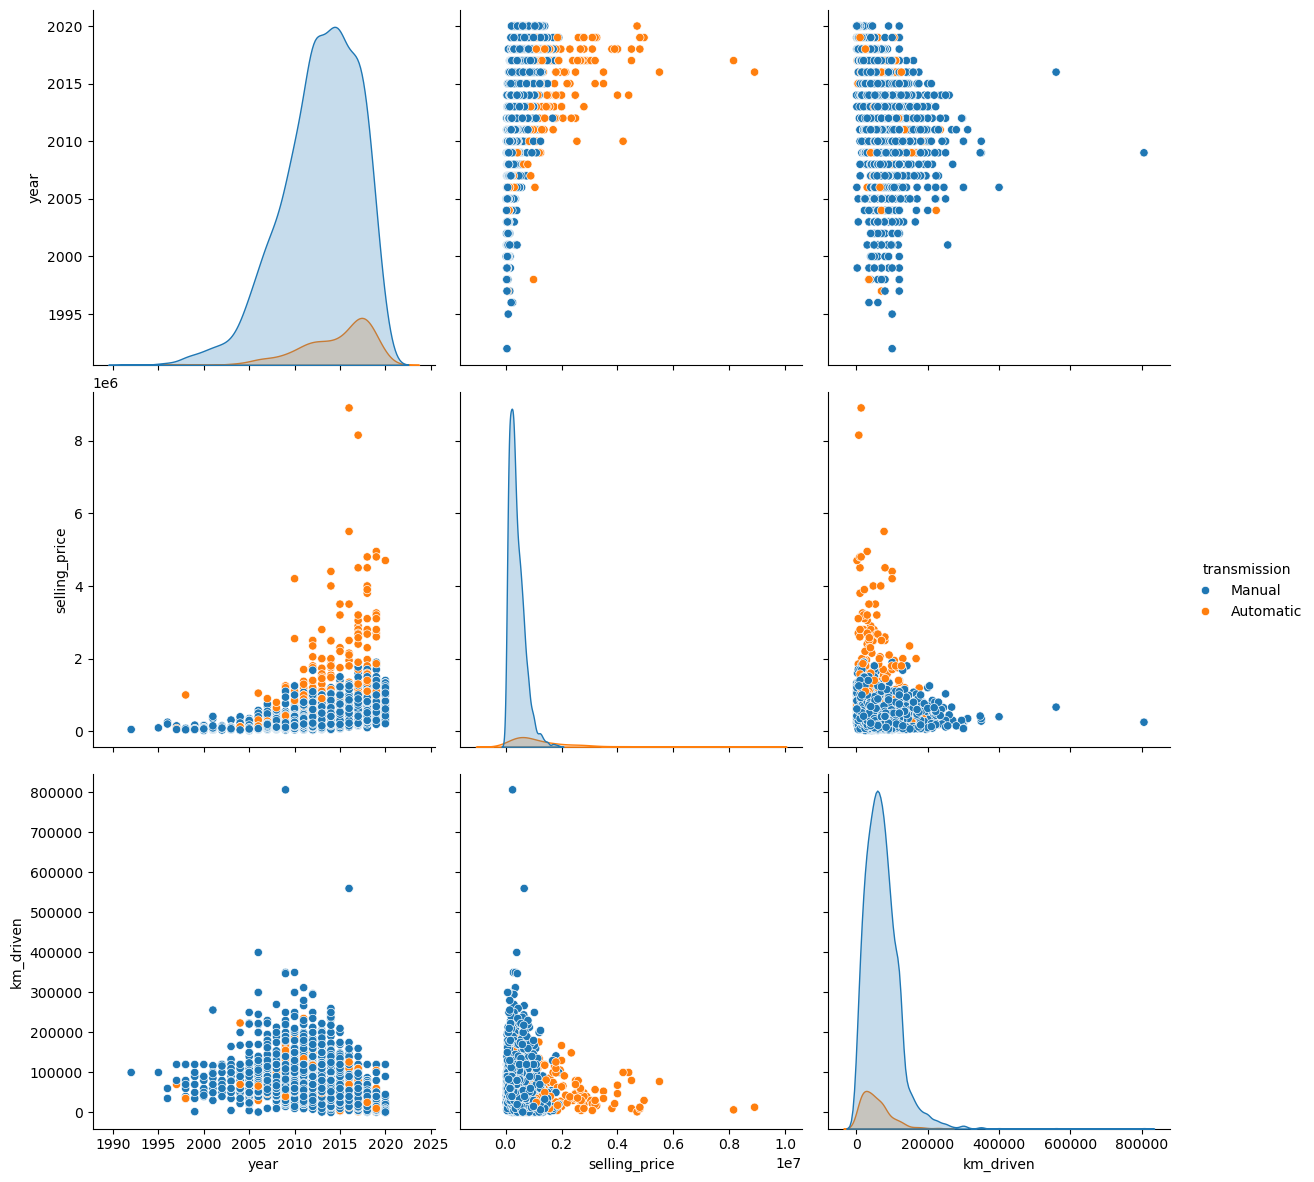

In [8]:
sns.pairplot(data=df, kind="scatter", diag_kind="kde", height=4, hue="transmission")

We can do some conclusions based on these plots:

1. Selling price tends to slowly go up with increasing of manufactoring year (can be seen if kind="reg", which shows regression line).
2. With more kilometers driven the price of the car lowers slightly (can be seen if kind="reg", which shows regression line).
3. Selling price is VERY dependant on a transmission type.

### Next lets analyse how categorical features influence car price

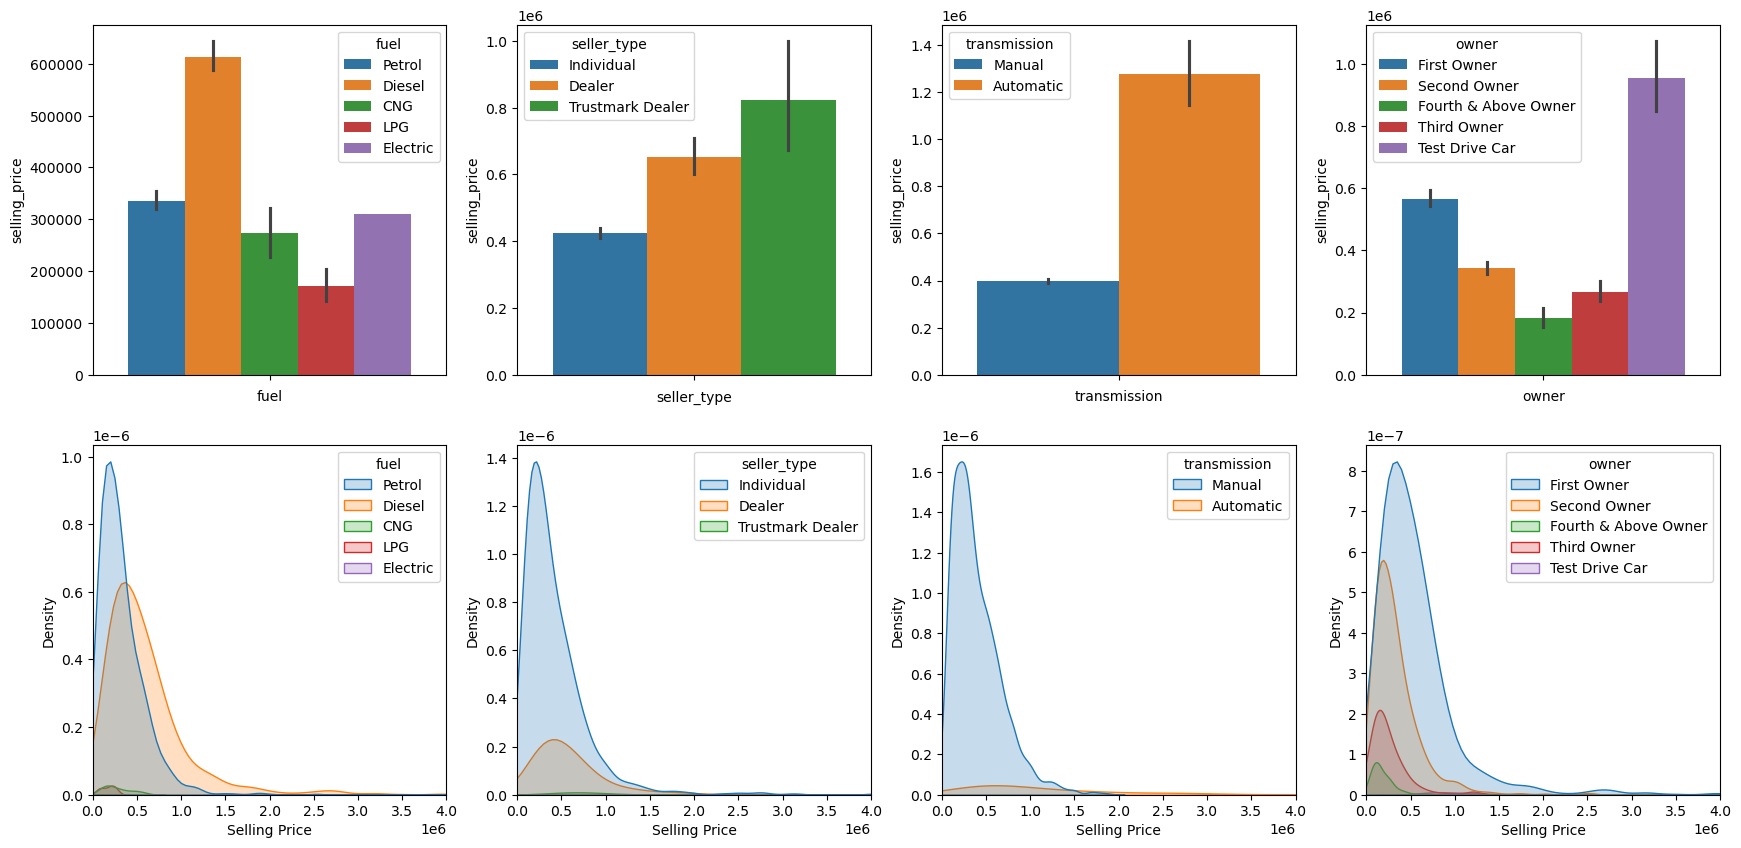

In [9]:
categorical = ['fuel', 'seller_type', 'transmission', 'owner']
fig, axs = plt.subplots(ncols=len(categorical), nrows=2, figsize=(21, 10))

for item in categorical:
    col_idx = categorical.index(item)
    sns.barplot(data=df, y="selling_price", ax=axs[0, col_idx], hue=item)
    axs[0, col_idx].set_xlabel(item)
    
    sns.kdeplot(data=df, x="selling_price", ax=axs[1, col_idx], hue=item, fill=True, warn_singular=False)
    axs[1, col_idx].set_xlim(0, 4e6)
    axs[1, col_idx].set_xlabel('Selling Price')

What can we conclude from these plots?

1. Diesel cars on average have bigger selling price, petrol is half the price on average. Electric car price is close to a mean price of a petrol car.
2. Trustmark dealer sellers got higher prices for cars. Dealer sellers prices are higher then individual sellers', but dealer sellers prices got wider spread.
3. Automatic transmission cars are more expensive.
4. The more owners the car had, the less its price will be.
5. Test drive cars are the most expensive ones.

## What did we achieve?

This dataset offered us information about car sales. 
During my analysis the "selling_price" column was picked as the target one since it gives us the most interesting and useful information. 
The analysis showed that car transmission, fuel type, seller type, and count of car owners all take part in price formation. 